Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scanning for gene files in: /content/drive/My Drive/Forest Plot Survival CGGA...
Found 63 files. Starting batch Cox regression...


/tmp/ipython-input-3255211810.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MT' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df[idh_col].astype(str).str.contains('Mutant', case=False), 'Group'] = 'MT'
/tmp/ipython-input-3255211810.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MT' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df[idh_col].astype(str).str.contains('Mutant', case=False), 'Group'] = 'MT'
/tmp/ipython-input-3255211810.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MT' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df[idh_col].astype(str).str.contains('Mutant


Plot saved to: /content/drive/My Drive/Forest Plot Survival CGGA/Comparative_Forest_Plot.png


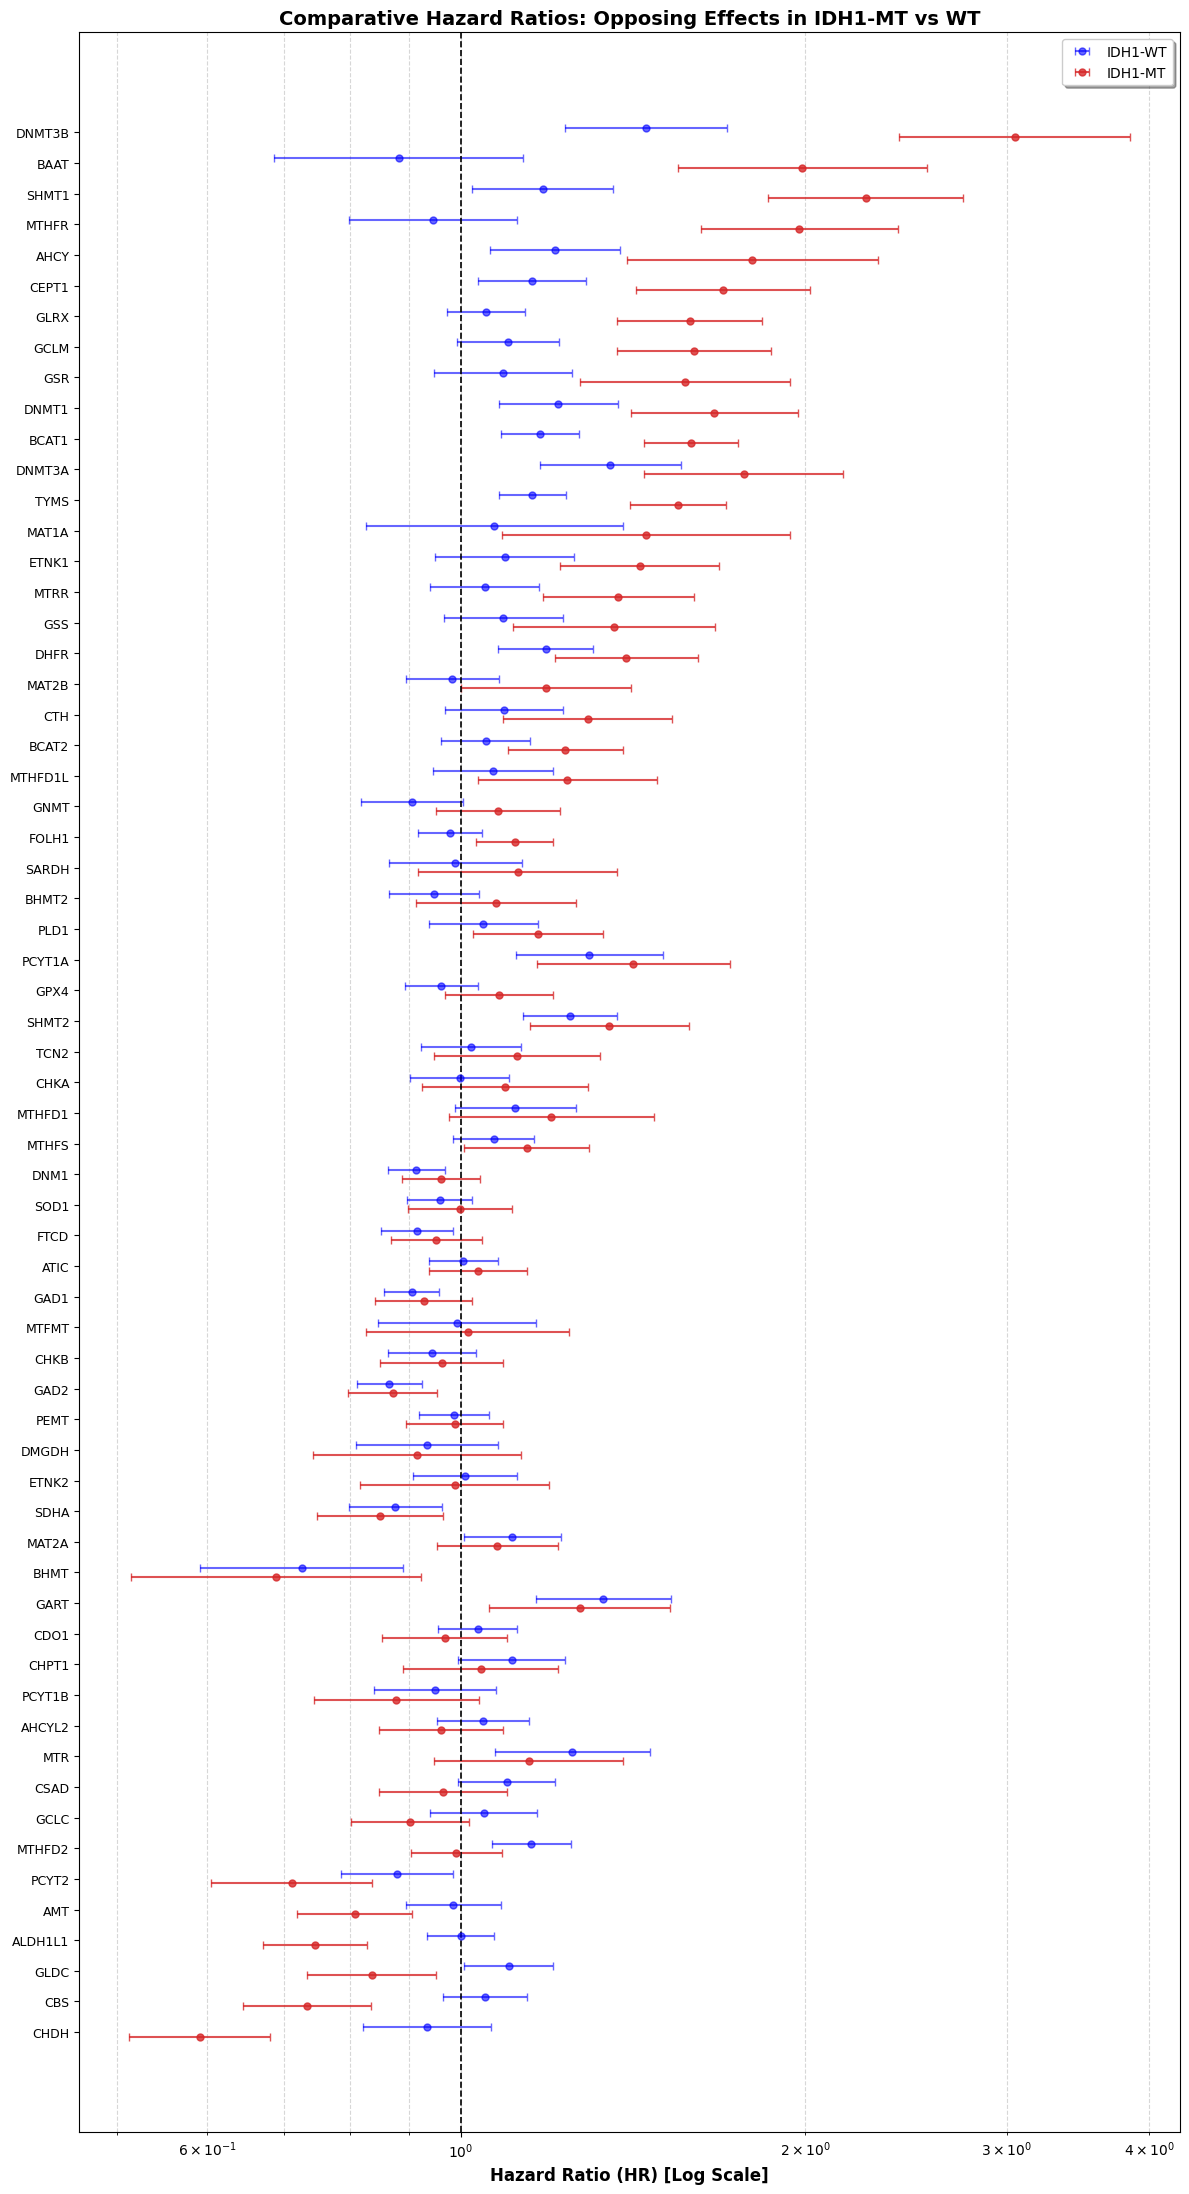


Identified 18 genes with opposing effects (HR crosses 1 between subtypes).
  Gene    HR_MT    HR_WT
   CBS 0.733972 1.049213
  GLDC 0.835389 1.100995
MTHFD2 0.990905 1.152084
  GCLC 0.902738 1.046877
  CSAD 0.964629 1.096405
AHCYL2 0.961512 1.045138
  CDO1 0.967963 1.034137
 ETNK2 0.987274 1.008784
 MTFMT 1.013553 0.991675
  CHKA 1.093290 0.997895
  GPX4 1.079156 0.961482
 BHMT2 1.073264 0.947588
 SARDH 1.120864 0.988860
 FOLH1 1.114351 0.978198
  GNMT 1.077197 0.905769
 MAT2B 1.187103 0.983259
 MTHFR 1.975574 0.945945
  BAAT 1.988825 0.882007


In [ ]:
# @title Install Dependencies
!pip install lifelines --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from google.colab import drive
from lifelines import CoxPHFitter

# --- 1. Mount Drive & Setup ---
drive.mount('/content/drive')

# Define the folder path
# Ensure this matches your folder name exactly
base_path = '/content/drive/My Drive/Forest Plot Survival CGGA'

# --- 2. Robust Data Loading & Analysis ---
results_list = []

print(f"Scanning for gene files in: {base_path}...")
files = glob.glob(os.path.join(base_path, "*.csv"))

if not files:
    print("ERROR: No CSV files found. Please check your folder name and path.")
else:
    print(f"Found {len(files)} files. Starting batch Cox regression...")

    for filepath in files:
        try:
            # Get gene name from filename (e.g., 'MTHFR.csv' -> 'MTHFR')
            gene_name = os.path.splitext(os.path.basename(filepath))[0]

            df = pd.read_csv(filepath)

            # --- Smart Column Detection ---
            # Finds the column that actually contains "Mutant" or "Wild_type"
            idh_col = None
            for col in df.columns:
                if df[col].astype(str).str.contains('Mutant|Wild_type', case=False, regex=True).any():
                    idh_col = col
                    break

            if idh_col is None:
                print(f"Skipping {gene_name}: Could not find IDH status column.")
                continue

            # Standardize Status Labels
            # Create a clean 'Group' column: 'MT' or 'WT'
            df['Group'] = np.nan
            df.loc[df[idh_col].astype(str).str.contains('Mutant', case=False), 'Group'] = 'MT'
            df.loc[df[idh_col].astype(str).str.contains('Wild_type', case=False), 'Group'] = 'WT'

            # Drop missing essential data
            # Ensure 'survival', 'status', 'mRNA' exist. (Case insensitive check could be added if needed)
            df = df.dropna(subset=['Group', 'survival', 'status', 'mRNA'])

            # Function to calculate HR
            def calculate_hr(cohort_df):
                if len(cohort_df) < 10: return np.nan, np.nan, np.nan # Not enough data
                cph = CoxPHFitter()
                # Fit mRNA expression against survival
                try:
                    cph.fit(cohort_df[['survival', 'status', 'mRNA']], duration_col='survival', event_col='status')
                    summary = cph.summary.loc['mRNA']
                    return summary['exp(coef)'], summary['exp(coef) lower 95%'], summary['exp(coef) upper 95%']
                except:
                    return np.nan, np.nan, np.nan

            # Run Analysis for MT and WT separately
            hr_mt, low_mt, high_mt = calculate_hr(df[df['Group'] == 'MT'])
            hr_wt, low_wt, high_wt = calculate_hr(df[df['Group'] == 'WT'])

            if not np.isnan(hr_mt) and not np.isnan(hr_wt):
                results_list.append({
                    'Gene': gene_name,
                    'HR_MT': hr_mt, 'Low_MT': low_mt, 'High_MT': high_mt,
                    'HR_WT': hr_wt, 'Low_WT': low_wt, 'High_WT': high_wt
                })

        except Exception as e:
            print(f"Error processing {gene_name}: {e}")

    # --- 3. Generate Comparative Forest Plot ---
    if not results_list:
        print("No valid results to plot.")
    else:
        res_df = pd.DataFrame(results_list)

        # Calculate Difference to sort by "Opposing Effects"
        # Genes with high MT risk and low WT risk will be at one end, and vice versa
        res_df['Diff'] = res_df['HR_MT'] - res_df['HR_WT']
        res_df = res_df.sort_values('Diff', ascending=True)

        # Plot Setup - Dynamic Height based on number of genes
        plt.figure(figsize=(12, max(6, len(res_df) * 0.35)))

        y_pos = np.arange(len(res_df))

        # Plot IDH1-WT (Blue)
        plt.errorbar(x=res_df['HR_WT'], y=y_pos + 0.15,
                     xerr=[res_df['HR_WT'] - res_df['Low_WT'], res_df['High_WT'] - res_df['HR_WT']],
                     fmt='o', color='blue', alpha=0.6, label='IDH1-WT', capsize=3, markersize=5)

        # Plot IDH1-MT (Red)
        plt.errorbar(x=res_df['HR_MT'], y=y_pos - 0.15,
                     xerr=[res_df['HR_MT'] - res_df['Low_MT'], res_df['High_MT'] - res_df['HR_MT']],
                     fmt='o', color='#D62728', alpha=0.8, label='IDH1-MT', capsize=3, markersize=5)

        # Visual Aids
        plt.axvline(x=1, color='black', linestyle='--', linewidth=1.2) # HR = 1 Reference
        plt.yticks(y_pos, res_df['Gene'], fontsize=9)
        plt.xlabel('Hazard Ratio (HR) [Log Scale]', fontsize=12, fontweight='bold')
        plt.title('Comparative Hazard Ratios: Opposing Effects in IDH1-MT vs WT', fontsize=14, fontweight='bold')

        # Grid and Legend
        plt.grid(axis='x', which='both', linestyle='--', alpha=0.5)
        plt.legend(loc='upper right', frameon=True, shadow=True)
        plt.xscale('log') # Log scale is standard for HR plots

        # Highlight Opposing Effects Area
        # Optional: Add shading or text to indicate risk zones
        # E.g. Top of list = High Risk WT / Low Risk MT
        # Bottom of list = Low Risk WT / High Risk MT

        plt.tight_layout()

        # Save
        save_path = os.path.join(base_path, 'Comparative_Forest_Plot.png')
        plt.savefig(save_path, dpi=1200, bbox_inches='tight')
        print(f"\nPlot saved to: {save_path}")
        plt.show()

        # Print Summary of Opposing Genes (HR > 1 in one, HR < 1 in other)
        opposing = res_df[((res_df['HR_MT'] > 1) & (res_df['HR_WT'] < 1)) |
                          ((res_df['HR_MT'] < 1) & (res_df['HR_WT'] > 1))]
        print(f"\nIdentified {len(opposing)} genes with opposing effects (HR crosses 1 between subtypes).")
        if not opposing.empty:
            print(opposing[['Gene', 'HR_MT', 'HR_WT']].to_string(index=False))


In [ ]:
csv_save_path = os.path.join(base_path, 'Opposing_Genes_HR_Summary.csv')
opposing.to_csv(csv_save_path, index=False)
print(f"Summary of opposing genes saved to: {csv_save_path}")

Summary of opposing genes saved to: /content/drive/My Drive/Forest Plot Survival CGGA/Opposing_Genes_HR_Summary.csv


Dual Volcano Plot

Found 63 files.
Successfully modeled 63 genes for plotting.
Plot saved to: /content/drive/MyDrive/Forest Plot Survival CGGA/Dual_Volcano_Plot_Academic_Enhanced.png


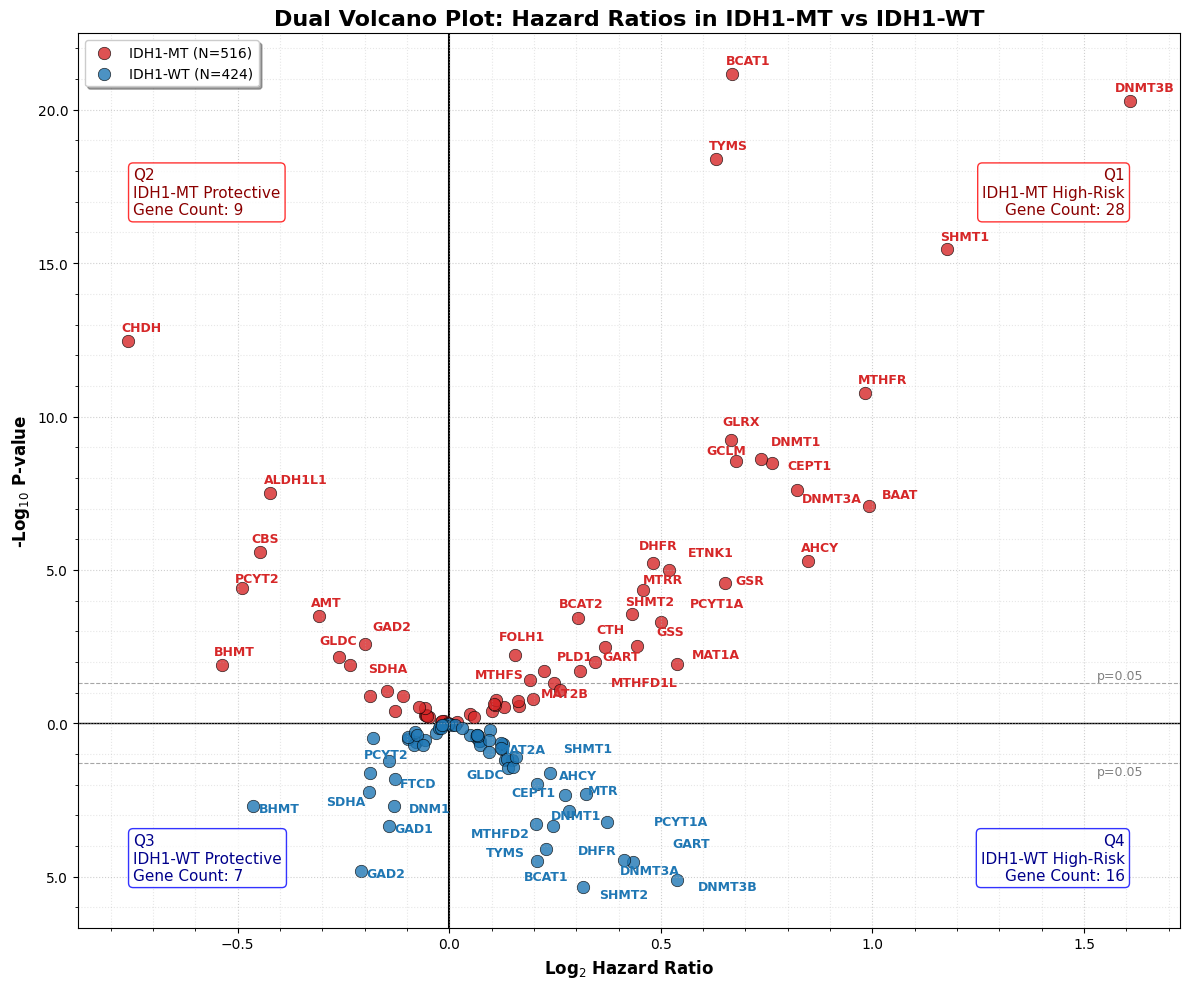


Gene HR/P-value summary saved to: /content/drive/MyDrive/Forest Plot Survival CGGA/Gene_HR_PValue_by_Quadrant.csv


In [ ]:
# @title Dual Volcano Plot (Academic Style Enhanced)
!pip install adjustText --quiet
!pip install lifelines --quiet

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from lifelines import CoxPHFitter
from google.colab import drive
from adjustText import adjust_text

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
FOLDER_PATH = '/content/drive/MyDrive/Forest Plot Survival CGGA'

# Exact Column Names from your sample
TIME_COL = 'survival'
EVENT_COL = 'status'
GENE_COL = 'mRNA'
IDH_COL = 'IDH_status'

# Target Values (Case Sensitive, but we will auto-strip spaces)
VAL_MT = 'Mutant'
VAL_WT = 'Wild_type'
# ---------------------------------------------------------

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

files = glob.glob(os.path.join(FOLDER_PATH, "*.csv"))
print(f"Found {len(files)} files.")

results = []

# --- Function to get cohort sizes from a representative file ---
def get_cohort_sizes(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    if IDH_COL not in df.columns: return np.nan, np.nan
    df[IDH_COL] = df[IDH_COL].astype(str).str.strip()
    n_mt = df[df[IDH_COL] == VAL_MT].shape[0]
    n_wt = df[df[IDH_COL] == VAL_WT].shape[0]
    return n_mt, n_wt

n_mt_cohort, n_wt_cohort = (np.nan, np.nan)
if files: # Get cohort sizes from the first file as a representative
    n_mt_cohort, n_wt_cohort = get_cohort_sizes(files[0])

for file_path in files:
    gene_name = os.path.basename(file_path).split('.')[0]

    try:
        df = pd.read_csv(file_path)

        # --- STEP 1: AUTO-CLEANING DATA ---
        # 1. Trim whitespace from Column Names
        df.columns = df.columns.str.strip()

        # 2. Check if required columns exist
        if not all(col in df.columns for col in [TIME_COL, EVENT_COL, GENE_COL, IDH_COL]):
            print(f"Skipping {gene_name}: Column mismatch. Found: {list(df.columns)}")
            continue

        # 3. Clean IDH Column (Remove spaces and ensure string)
        df[IDH_COL] = df[IDH_COL].astype(str).str.strip()

        # 4. Force Survival/Status to Numeric (Turn 'NA' into NaN)
        df[TIME_COL] = pd.to_numeric(df[TIME_COL], errors='coerce')
        df[EVENT_COL] = pd.to_numeric(df[EVENT_COL], errors='coerce')

        # 5. Drop rows with missing survival data
        df = df.dropna(subset=[TIME_COL, EVENT_COL, IDH_COL])

        # --- STEP 2: COX REGRESSION ---
        def get_hr(sub_df, cohort_name, time_col, event_col, gene_col):
            # Must have at least 2 distinct events (death=1) to fit a curve
            if sub_df.empty:
                print(f"  Skipping {gene_name} {cohort_name}: Cohort is empty after dropping NaNs.")
                return np.nan, np.nan
            if sub_df[event_col].sum() < 2:
                print(f"  Skipping {gene_name} {cohort_name}: Fewer than 2 events.")
                return np.nan, np.nan
            try:
                cph = CoxPHFitter()
                cph.fit(sub_df[[time_col, event_col, gene_col]],
                        duration_col=time_col, event_col=event_col)
                return cph.hazard_ratios_[gene_col], cph.summary.loc[gene_col, 'p']
            except Exception as e:
                print(f"  Skipping {gene_name} {cohort_name}: CoxPHFitter failed - {e}")
                return np.nan, np.nan

        # Analyze Mutant
        mt_data = df[df[IDH_COL] == VAL_MT]
        hr_mt, p_mt = get_hr(mt_data, 'MT', TIME_COL, EVENT_COL, GENE_COL)

        # Analyze Wild_type
        wt_data = df[df[IDH_COL] == VAL_WT]
        hr_wt, p_wt = get_hr(wt_data, 'WT', TIME_COL, EVENT_COL, GENE_COL)

        # Always append to results, even if HR/P values are NaN for one or both
        results.append({
            'Gene': gene_name,
            'HR_MT': hr_mt, 'P_MT': p_mt,
            'HR_WT': hr_wt, 'P_WT': p_wt
        })

    except Exception as e:
        print(f"Error processing {gene_name}: {e}")

# --- STEP 3: PLOTTING ---
# Create the full DataFrame from results for CSV output (includes NaNs)
full_df = pd.DataFrame(results)

# Filter for plotting: only include genes with valid HR/P for both MT and WT
plot_df = full_df.dropna(subset=['HR_MT', 'P_MT', 'HR_WT', 'P_WT'])

if len(plot_df) > 0:
    print(f"Successfully modeled {len(plot_df)} genes for plotting.")

    # Data Transforms
    plot_df['log2_HR_MT'] = np.log2(plot_df['HR_MT'])
    plot_df['log2_HR_WT'] = np.log2(plot_df['HR_WT'])
    plot_df['y_MT'] = -np.log10(plot_df['P_MT'])
    plot_df['y_WT'] = -(-np.log10(plot_df['P_WT'])) # Invert for symmetry below x-axis

    # Set global font size for academic look
    plt.rcParams.update({'font.size': 10})

    fig, ax = plt.subplots(figsize=(12, 10)) # Slightly adjusted figure size

    # Plot Points (IDH1-MT in Red, IDH1-WT in Blue)
    # Using standard matplotlib colors or hex for consistency
    ax.scatter(plot_df['log2_HR_MT'], plot_df['y_MT'], c='#d62728', label=f'IDH1-MT (N={int(n_mt_cohort) if not np.isnan(n_mt_cohort) else "NA"})', alpha=0.8, s=80, edgecolors='black', linewidth=0.5) # Red
    ax.scatter(plot_df['log2_HR_WT'], plot_df['y_WT'], c='#1f77b4', label=f'IDH1-WT (N={int(n_wt_cohort) if not np.isnan(n_wt_cohort) else "NA"})', alpha=0.8, s=80, edgecolors='black', linewidth=0.5) # Blue

    # Lines
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, zorder=0) # HR = 1 (Log2 HR = 0) reference
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=0)

    sig_thresh = -np.log10(0.05)
    ax.axhline(y=sig_thresh, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    ax.axhline(y=-sig_thresh, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    ax.text(ax.get_xlim()[1] * 0.95, sig_thresh + 0.05, 'p=0.05', va='bottom', ha='right', color='gray', fontsize=9)
    ax.text(ax.get_xlim()[1] * 0.95, -sig_thresh - 0.05, 'p=0.05', va='top', ha='right', color='gray', fontsize=9)

    # Add Grid
    ax.grid(True, which='major', linestyle=':', alpha=0.6, zorder=0)
    ax.grid(True, which='minor', linestyle=':', alpha=0.3, zorder=0)
    ax.minorticks_on()

    # Generate labels only for significant genes
    texts = []
    points_x = []
    points_y = []

    # Filtering for significant genes based on the threshold
    significant_df_mt = plot_df[plot_df['y_MT'] > sig_thresh]
    significant_df_wt = plot_df[plot_df['y_WT'] < -sig_thresh] # Note: y_WT is negative log10 p-value, so less than -threshold means significant

    for i, row in significant_df_mt.iterrows():
        texts.append(ax.text(row['log2_HR_MT'], row['y_MT'], row['Gene'],
                             fontsize=9, ha='center', va='bottom', color='#d62728', weight='bold')) # Red
        points_x.append(row['log2_HR_MT'])
        points_y.append(row['y_MT'])

    for i, row in significant_df_wt.iterrows():
        texts.append(ax.text(row['log2_HR_WT'], row['y_WT'], row['Gene'],
                             fontsize=9, ha='center', va='top', color='#1f77b4', weight='bold')) # Blue
        points_x.append(row['log2_HR_WT'])
        points_y.append(row['y_WT'])

    # Adjust texts to prevent overlaps (no arrows)
    if texts:
        adjust_text(texts,
                    x=points_x,
                    y=points_y,
                    arrowprops=None, # Remove connecting lines
                    expand_points=(2, 2),
                    force_points=(0.5, 0.5),
                    force_text=(0.5, 0.5),
                    lim=200
                   )

    # -------------------------------------------------------
    # 2. QUADRANT ANNOTATIONS (User-specified style)
    # -------------------------------------------------------
    # Helper for adding box labels
    props_mt = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red')
    props_wt = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='blue')

    # Calculate counts for each quadrant (significant genes only)
    # These counts should be based on the 'plot_df' as they relate to visual elements on the plot
    count_q1_mt_risk = plot_df[(plot_df['log2_HR_MT'] > 0) & (plot_df['y_MT'] > sig_thresh)].shape[0]
    count_q2_mt_prot = plot_df[(plot_df['log2_HR_MT'] < 0) & (plot_df['y_MT'] > sig_thresh)].shape[0]
    count_q3_wt_prot = plot_df[(plot_df['log2_HR_WT'] < 0) & (plot_df['y_WT'] < -sig_thresh)].shape[0]
    count_q4_wt_risk = plot_df[(plot_df['log2_HR_WT'] > 0) & (plot_df['y_WT'] < -sig_thresh)].shape[0]

    # Top Right (MT Risk)
    ax.text(0.95, 0.85, f"Q1\nIDH1-MT High-Risk\nGene Count: {count_q1_mt_risk}", transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right', color='darkred', bbox=props_mt)

    # Top Left (MT Protective)
    ax.text(0.05, 0.85, f"Q2\nIDH1-MT Protective\nGene Count: {count_q2_mt_prot}", transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='left', color='darkred', bbox=props_mt)

    # Bottom Right (WT Risk)
    ax.text(0.95, 0.05, f"Q4\nIDH1-WT High-Risk\nGene Count: {count_q4_wt_risk}", transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='right', color='darkblue', bbox=props_wt)

    # Bottom Left (WT Protective)
    ax.text(0.05, 0.05, f"Q3\nIDH1-WT Protective\nGene Count: {count_q3_wt_prot}", transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', horizontalalignment='left', color='darkblue', bbox=props_wt)

    # Formatting
    ax.set_title('Dual Volcano Plot: Hazard Ratios in IDH1-MT vs IDH1-WT', fontsize=16, fontweight='bold')
    ax.set_xlabel('Log$_2$ Hazard Ratio', fontsize=12, fontweight='bold')
    ax.set_ylabel('-Log$_{10}$ P-value', fontsize=12, fontweight='bold')

    # Formatter for Y-axis (Absolute values)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{abs(x):.1f}"))

    # Adjust legend position for better aesthetics
    ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

    plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping
    save_path = os.path.join(FOLDER_PATH, 'Dual_Volcano_Plot_Academic_Enhanced.png')
    plt.savefig(save_path, dpi=1200) # Higher DPI for academic quality
    print(f"Plot saved to: {save_path}")
    plt.show()

else:
    print("No genes with valid HR/P-values for both MT and WT found to plot.")

# --- CSV Output for Quadrant Analysis (All genes) ---
csv_output_df = full_df.copy() # Use the full DataFrame including NaNs

# Assign each gene to a quadrant category based on HR directions
# HR >= 1 is considered 'Risk', HR < 1 is 'Protective'
# If HR is NaN, it won't satisfy these conditions, leaving Quadrant_Category empty
csv_output_df['Quadrant_Category'] = ''

cond_mt_risk = csv_output_df['HR_MT'] >= 1
cond_mt_prot = csv_output_df['HR_MT'] < 1
cond_wt_risk = csv_output_df['HR_WT'] >= 1
cond_wt_prot = csv_output_df['HR_WT'] < 1

csv_output_df.loc[cond_mt_risk & cond_wt_risk, 'Quadrant_Category'] = 'MT_Risk_WT_Risk'
csv_output_df.loc[cond_mt_risk & cond_wt_prot, 'Quadrant_Category'] = 'MT_Risk_WT_Protective'
csv_output_df.loc[cond_mt_prot & cond_wt_risk, 'Quadrant_Category'] = 'MT_Protective_WT_Risk'
csv_output_df.loc[cond_mt_prot & cond_wt_prot, 'Quadrant_Category'] = 'MT_Protective_WT_Protective'

# Add the new 'Significant_Quadrants' column
# Recalculate log2_HR and y_values for the full_df (csv_output_df) for quadrant assignment
csv_output_df['log2_HR_MT_temp'] = np.log2(csv_output_df['HR_MT'])
csv_output_df['log2_HR_WT_temp'] = np.log2(csv_output_df['HR_WT'])
csv_output_df['y_MT_temp'] = -np.log10(csv_output_df['P_MT'])
csv_output_df['y_WT_temp'] = -(-np.log10(csv_output_df['P_WT'])) # Invert for symmetry below x-axis

def get_significant_quadrants_csv(row, sig_thresh):
    quadrants = []
    # Q1: IDH1-MT High-Risk Significant
    if pd.notna(row['log2_HR_MT_temp']) and pd.notna(row['y_MT_temp']) and \
       (row['log2_HR_MT_temp'] > 0) and (row['y_MT_temp'] > sig_thresh):
        quadrants.append('Q1')
    # Q2: IDH1-MT Protective Significant
    if pd.notna(row['log2_HR_MT_temp']) and pd.notna(row['y_MT_temp']) and \
       (row['log2_HR_MT_temp'] < 0) and (row['y_MT_temp'] > sig_thresh):
        quadrants.append('Q2')
    # Q3: IDH1-WT Protective Significant
    if pd.notna(row['log2_HR_WT_temp']) and pd.notna(row['y_WT_temp']) and \
       (row['log2_HR_WT_temp'] < 0) and (row['y_WT_temp'] < -sig_thresh):
        quadrants.append('Q3')
    # Q4: IDH1-WT High-Risk Significant
    if pd.notna(row['log2_HR_WT_temp']) and pd.notna(row['y_WT_temp']) and \
       (row['log2_HR_WT_temp'] > 0) and (row['y_WT_temp'] < -sig_thresh):
        quadrants.append('Q4')

    if not quadrants:
        return 'None Significant'
    else:
        return ', '.join(quadrants)

sig_thresh_csv = -np.log10(0.05) # Ensure sig_thresh is defined for this scope
csv_output_df['Significant_Quadrants'] = csv_output_df.apply(lambda row: get_significant_quadrants_csv(row, sig_thresh_csv), axis=1)

# Drop temporary columns used for quadrant assignment
csv_output_df = csv_output_df.drop(columns=['log2_HR_MT_temp', 'log2_HR_WT_temp', 'y_MT_temp', 'y_WT_temp'], errors='ignore')

# Introduce a combined significance metric for sorting within quadrants
# Min_P_Value: Lower value means higher significance. NaNs will sort to the end.
csv_output_df['Min_P_Value'] = csv_output_df[['P_MT', 'P_WT']].min(axis=1)

# Sort each quadrant category by significance
sorted_quadrants = []
# Handle potential empty categories or categories with only NaNs
for category in csv_output_df['Quadrant_Category'].unique():
    quadrant_df = csv_output_df[csv_output_df['Quadrant_Category'] == category].sort_values(by='Min_P_Value', ascending=True)
    sorted_quadrants.append(quadrant_df)

# Concatenate sorted quadrants. Handle if sorted_quadrants is empty.
if sorted_quadrants:
    final_csv_df = pd.concat(sorted_quadrants)
else:
    final_csv_df = csv_output_df.copy() # If no categories, just keep original data with NaNs

# Sort any genes not assigned a quadrant (e.g., due to NaNs) to the end
# Ensure Min_P_Value is available for this sort
final_csv_df['Is_Quadrant_Assigned'] = final_csv_df['Quadrant_Category'].apply(lambda x: not pd.isna(x) and x != '')
final_csv_df = final_csv_df.sort_values(by=['Is_Quadrant_Assigned', 'Quadrant_Category', 'Min_P_Value'], ascending=[False, True, True])
final_csv_df = final_csv_df.drop(columns=['Is_Quadrant_Assigned', 'Min_P_Value']) # Drop temporary columns after use

# Save to CSV
csv_save_path = os.path.join(FOLDER_PATH, 'Gene_HR_PValue_by_Quadrant.csv')
final_csv_df.to_csv(csv_save_path, index=False)
print(f"\nGene HR/P-value summary saved to: {csv_save_path}")
